# Testing and saving a DQN architecture to solve Blockblast

In [ ]:
import gymnasium as gym
import torch
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from blockblast.block_blast_3p_env import BlockBlast3PEnv
from dqn import DQNAgent, BlockBlastCNNNet

from pathlib import Path
from IPython.display import Video

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
env = BlockBlast3PEnv(render_mode=None)
agent = DQNAgent(action_size=192)

In [4]:
print(f"Nombre de paramètres: {len(torch.nn.utils.parameters_to_vector(agent.policy_net.parameters()))}")

Nombre de paramètres: 2709696


# Training

In [ ]:
# training hyperparameters
num_episodes = 5000
batch_size = 64

target_update_freq = 10

# learning rate
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

# save
training_name = "model_ep"
project_root = Path("../").resolve() 
checkpoint_dir = project_root / "checkpoints" / training_name
checkpoint_dir.mkdir(parents=True, exist_ok=True)
save_freq = None

In [ ]:
rewards_history = []

for episode in tqdm(range(num_episodes)):
    state, info = env.reset()
    episode_reward = 0
    done = False
    
    while not done:
        action = agent.select_action(state, epsilon)
        
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        # store in replay buffer
        agent.store_transition(state, action, reward, next_state, done)
        
        loss = agent.update_model()
        
        state = next_state
        episode_reward += reward
        
    # update the target network
    if episode % target_update_freq == 0:
        agent.update_target_model()
        
    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards_history.append(episode_reward)
    
    # saves
    if save_freq is not None and episode % save_freq == 0:
        agent.save_model(checkpoint_dir / f"{training_name}_{episode}.pth")

# final save
agent.save_model(checkpoint_dir / f"{training_name}_final.pth")

100%|██████████| 5000/5000 [12:48<00:00,  6.51it/s]


# Results

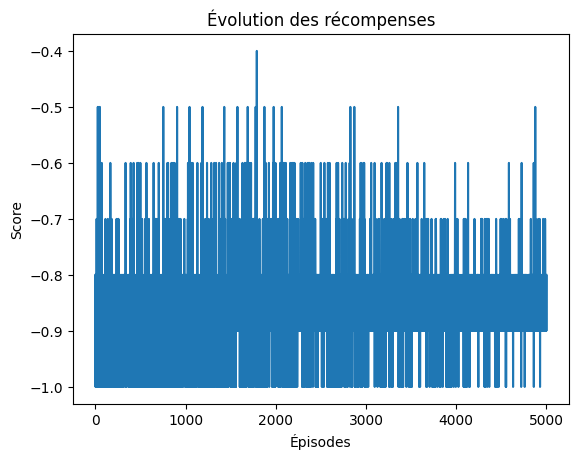

In [9]:
plt.plot(rewards_history)
plt.title("Évolution des récompenses")
plt.xlabel("Épisodes")
plt.ylabel("Score")
plt.show()

# Testing the agent

In [13]:
# Dossier de sortie
VIDEO_DIR = Path("./videos")
VIDEO_DIR.mkdir(exist_ok=True)
PREFIX = "block_blast_dqn"

env_base = BlockBlast3PEnv(render_mode="rgb_array")

# 2. Ajout du wrapper RecordVideo
# trigger=lambda e: True permet d'enregistrer TOUTES les épisodes lancées
env = gym.wrappers.RecordVideo(
    env_base, 
    video_folder=str(VIDEO_DIR), 
    name_prefix=PREFIX,
    episode_trigger=lambda e: True 
)

agent = DQNAgent(action_size=192)
agent.load_model("dqn/checkpoints/model_ep_4900.pth")

# --- Boucle de Test ---
observation, info = env.reset()
done = False

while not done:
    action = agent.select_action(observation, epsilon=0)
    observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    
    # stopping frame
    for _ in range(15): 
        env.render()

    if done:
        break

env.close()

# --- Affichage de la vidéo ---
# RecordVideo nomme souvent le fichier "name_prefix-episode-0.mp4"
Video(
    VIDEO_DIR / f"{PREFIX}-episode-0.mp4",
    embed=True,
    html_attributes="controls autoplay loop",
)

/home/arthur/RL_project/.venv/lib/python3.14/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/arthur/RL_project/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
